# Project Work

## Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Data Loading

In [2]:
booknow_booking = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv')
booknow_theaters = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv')
booknow_visits = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv')
cinePOS_booking = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv')
cinePOS_theaters = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv')
date_info = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv')
movie_theater_id_relation = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv')
sample_submission = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv')


In [3]:
datasets = {
    'booknow_booking': booknow_booking,
    'booknow_theaters': booknow_theaters,
    'booknow_visits': booknow_visits,
    'cinePOS_booking': cinePOS_booking,
    'cinePOS_theaters': cinePOS_theaters,
    'date_info': date_info,
    'movie_theater_id_relation': movie_theater_id_relation,
    'sample_submission': sample_submission
}

## EDA

### Basic Dataset Information

In [4]:
print("Basic Dataset Information:")
for name, df in datasets.items():
    print(f"\n{name}:")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Data types:\n{df.dtypes}")

Basic Dataset Information:

booknow_booking:
Shape: (68336, 4)
Columns: ['book_theater_id', 'show_datetime', 'booking_datetime', 'tickets_booked']
Data types:
book_theater_id     object
show_datetime       object
booking_datetime    object
tickets_booked       int64
dtype: object

booknow_theaters:
Shape: (829, 5)
Columns: ['book_theater_id', 'theater_type', 'theater_area', 'latitude', 'longitude']
Data types:
book_theater_id     object
theater_type        object
theater_area        object
latitude           float64
longitude          float64
dtype: object

booknow_visits:
Shape: (214046, 3)
Columns: ['book_theater_id', 'show_date', 'audience_count']
Data types:
book_theater_id    object
show_date          object
audience_count      int64
dtype: object

cinePOS_booking:
Shape: (1641966, 4)
Columns: ['cine_theater_id', 'show_datetime', 'booking_datetime', 'tickets_sold']
Data types:
cine_theater_id     object
show_datetime       object
booking_datetime    object
tickets_sold         int

### First Few Rows

In [5]:
# print("\n=== First Few Rows of Each Dataset ===")
# datasets = {
#     'booknow_booking': booknow_booking,
#     'booknow_theaters': booknow_theaters,
#     'booknow_visits': booknow_visits,
#     'cinePOS_booking': cinePOS_booking,
#     'cinePOS_theaters': cinePOS_theaters,
#     'date_info': date_info,
#     'movie_theater_id_relation': movie_theater_id_relation
# }

# for name, df in datasets.items():
#     print(f"\n{name}:")
#     print(df.head(2))
#     print(f"Columns: {df.columns.tolist()}")

### Target Variable Analysis

In [6]:
print("Target Variable Analysis (booknow_visits):")
target = booknow_visits['audience_count']
print(f"Mean: {target.mean():.2f}")
print(f"Median: {target.median():.2f}")
print(f"Std: {target.std():.2f}")
print(f"Min: {target.min()}")
print(f"Max: {target.max()}")
print(f"Skewness: {target.skew():.2f}")

Target Variable Analysis (booknow_visits):
Mean: 41.62
Median: 34.00
Std: 32.83
Min: 2
Max: 1350
Skewness: 2.60


Target Variable Visualization (booknow_visits):


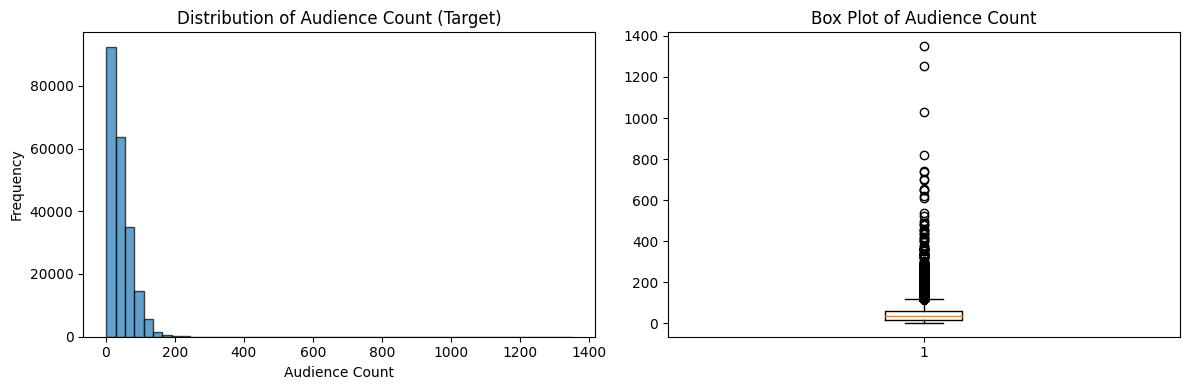

In [7]:
print("Target Variable Visualization (booknow_visits):")
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(target, bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribution of Audience Count (Target)')
plt.xlabel('Audience Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.boxplot(target)
plt.title('Box Plot of Audience Count')
plt.tight_layout()
plt.show()

### Time Series Analysis

Time Series Analysis:


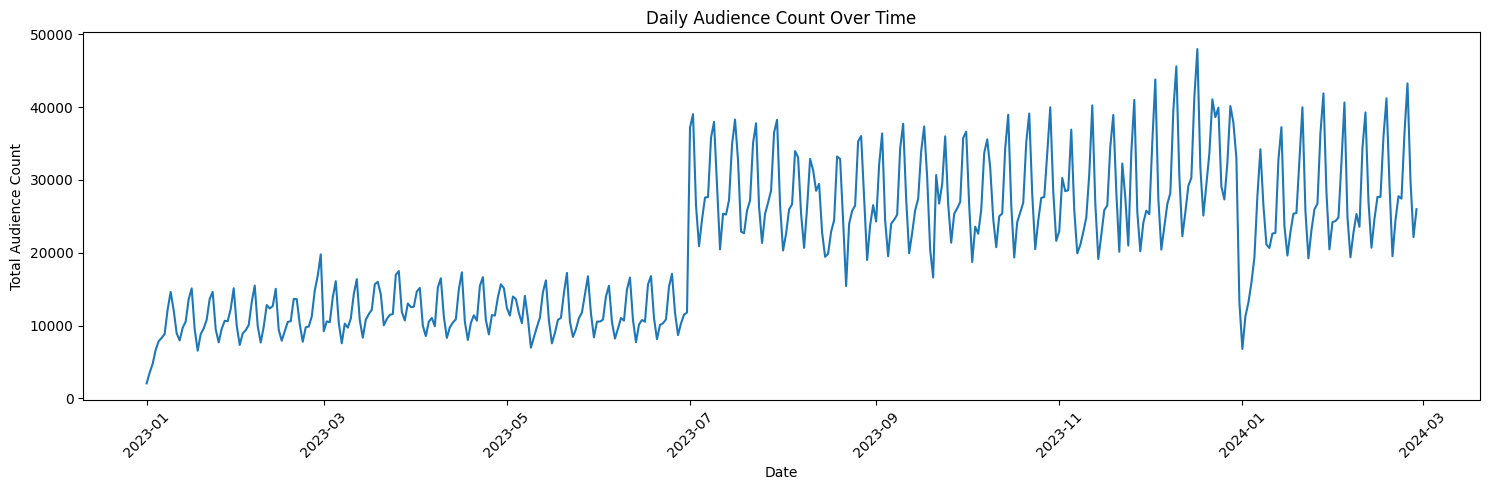

In [8]:
print("Time Series Analysis:")
booknow_visits['show_date'] = pd.to_datetime(booknow_visits['show_date'])
daily_audience = booknow_visits.groupby('show_date')['audience_count'].sum().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(daily_audience['show_date'], daily_audience['audience_count'])
plt.title('Daily Audience Count Over Time')
plt.xlabel('Date')
plt.ylabel('Total Audience Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Theater-wise Analysis

Theater-Wise Analysis:
Top 10 theaters by average audience:
    book_theater_id        mean        std  count
167      book_00169  127.543147  32.420301    197
93       book_00095  127.132743  82.204830    113
150      book_00152  108.880000  74.464936     25
487      book_00490  105.000000  33.959189    182
156      book_00158  101.113772  62.422812    167
585      book_00589   98.449102  40.816613    334
488      book_00491   94.506329  21.832623     79
592      book_00596   93.478261  86.251760     46
290      book_00292   93.465241  56.153138    187
712      book_00716   93.200000  15.775371    155


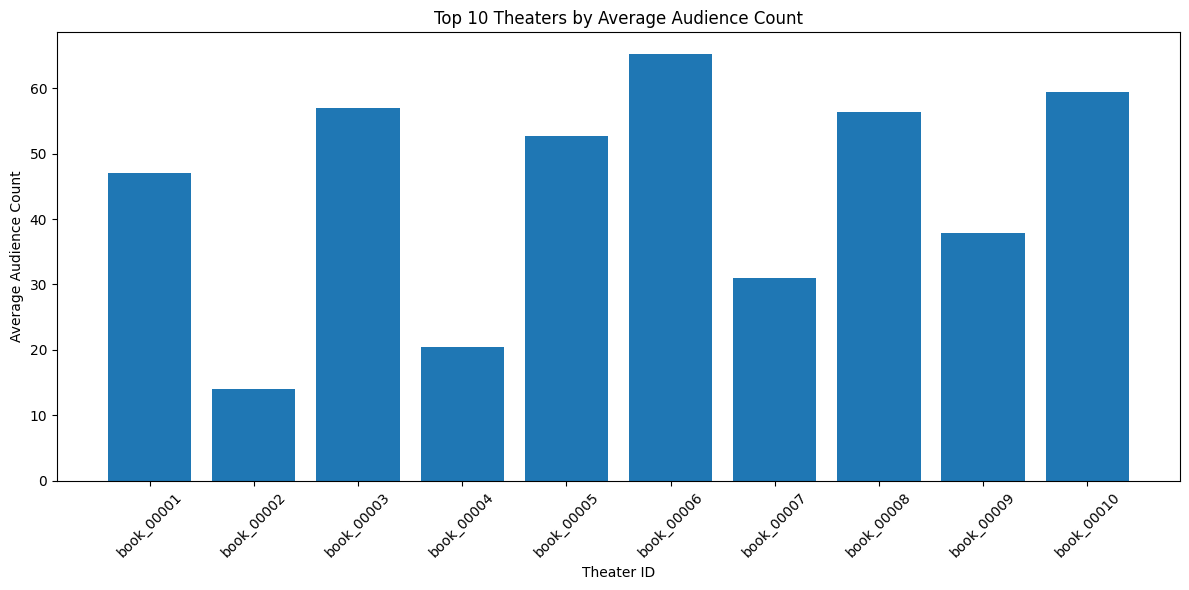

In [9]:
print("Theater-Wise Analysis:")
theater_stats = booknow_visits.groupby('book_theater_id')['audience_count'].agg(['mean', 'std', 'count']).reset_index()
print("Top 10 theaters by average audience:")
print(theater_stats.sort_values('mean', ascending=False).head(10))

plt.figure(figsize=(12, 6))
plt.bar(theater_stats['book_theater_id'].head(10), theater_stats['mean'].head(10))
plt.title('Top 10 Theaters by Average Audience Count')
plt.xlabel('Theater ID')
plt.ylabel('Average Audience Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Data Cleaning

### Missing Values Treatment

In [10]:
print("Missing Values Treatment:")
def handle_missing_values(df, name):
    print(f"\n{name}:")
    missing_before = df.isnull().sum().sum()
    
    if missing_before > 0:
        missing_cols = df.isnull().sum()
        missing_cols = missing_cols[missing_cols > 0]
        
        for col, missing_count in missing_cols.items():
            missing_pct = (missing_count / len(df)) * 100
            print(f"{col}: {missing_count} missing ({missing_pct:.2f}%)")
            
            if missing_pct > 50:
                df = df.drop(col, axis=1)
                print(f"Dropped column (high missing %)")
            else:
                if df[col].dtype in ['float64', 'int64']:
                    # Using median for numerical variables
                    fill_value = df[col].median()
                    df[col] = df[col].fillna(fill_value)
                    print(f"Filled with median: {fill_value}")
                else:
                    # Using mode for categorical variables
                    fill_value = df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown'
                    df[col] = df[col].fillna(fill_value)
                    print(f"Filled with mode: {fill_value}")
    
    missing_after = df.isnull().sum().sum()
    print(f"Missing values: {missing_before}  {missing_after}")
    return df
    
cleaned_datasets = {}
for name, df in datasets.items():
    if name != 'sample_submission':  
        cleaned_datasets[name] = handle_missing_values(df.copy(), name)
        

Missing Values Treatment:

booknow_booking:
Missing values: 0  0

booknow_theaters:
book_theater_id: 515 missing (62.12%)
Dropped column (high missing %)
Missing values: 515  0

booknow_visits:
Missing values: 0  0

cinePOS_booking:
Missing values: 0  0

cinePOS_theaters:
latitude: 3861 missing (82.32%)
Dropped column (high missing %)
longitude: 3861 missing (82.32%)
Dropped column (high missing %)
Missing values: 7722  0

date_info:
Missing values: 0  0

movie_theater_id_relation:
Missing values: 0  0


bnb, bnv, cpb, dt, mtir all zeo  missing values and dropped cpt 

### Removing Duplicates

In [11]:
print("Duplicate Removal:")
def remove_duplicates(df, name):
    duplicates_before = df.duplicated().sum()
    
    if duplicates_before > 0:
        print(f"{name}: Found {duplicates_before} duplicates")
        
        # checking for meaningful duplicates 
        if 'book_theater_id' in df.columns and 'show_date' in df.columns:
            meaningful_dups = df.duplicated(subset=['book_theater_id', 'show_date']).sum()
            if meaningful_dups > 0:
                df = df.drop_duplicates(subset=['book_theater_id', 'show_date'], keep='first')
                print(f"Removed {meaningful_dups} meaningful duplicates (same theater + date)")
        else:
            df = df.drop_duplicates()
            print(f"Removed all duplicates")
    
    duplicates_after = df.duplicated().sum()
    if duplicates_before != duplicates_after:
        print(f"Duplicates: {duplicates_before}  {duplicates_after}")
    
    return df

for name, df in cleaned_datasets.items():
    cleaned_datasets[name] = remove_duplicates(df, name)

Duplicate Removal:
booknow_booking: Found 2042 duplicates
Removed all duplicates
Duplicates: 2042  0
booknow_theaters: Found 647 duplicates
Removed all duplicates
Duplicates: 647  0
booknow_visits: Found 10 duplicates
Removed 175 meaningful duplicates (same theater + date)
Duplicates: 10  0
cinePOS_booking: Found 12541 duplicates
Removed all duplicates
Duplicates: 12541  0


### Managing Outliers

In [12]:
print("Managing Outliers:")
def handle_outliers(df, name):
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    
    for col in numerical_cols:
        # Only process columns with sufficient variability
        if df[col].nunique() > 10 and col != 'book_theater_id':  # Skip ID columns
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
            outlier_pct = (len(outliers) / len(df)) * 100
            
            if outlier_pct > 0:
                print(f"{name} - {col}: {len(outliers)} outliers ({outlier_pct:.2f}%)")
                
                if outlier_pct < 5:  # Cap only small % outliers
                    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
                    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
                    print(f"Capped outliers to bounds [{lower_bound:.2f}, {upper_bound:.2f}]")
                else:
                    print(f"Keeping outliers (natural variation)")
    
    return df

# Applying outlier treatment to main datasets
for name in ['booknow_visits', 'booknow_booking', 'cinePOS_booking']:
    if name in cleaned_datasets:
        cleaned_datasets[name] = handle_outliers(cleaned_datasets[name], name)


Managing Outliers:
booknow_visits - audience_count: 5587 outliers (2.61%)
Capped outliers to bounds [-42.00, 118.00]
booknow_booking - tickets_booked: 5523 outliers (8.33%)
Keeping outliers (natural variation)
cinePOS_booking - tickets_sold: 100015 outliers (6.14%)
Keeping outliers (natural variation)


### Target Variable Outliers

In [13]:
print("Special Outlier Treatment for Audience_Count:")
if 'booknow_visits' in cleaned_datasets:
    audience_data = cleaned_datasets['booknow_visits']['audience_count']
    Q1 = audience_data.quantile(0.25)
    Q3 = audience_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = max(0, Q1 - 1.5 * IQR)  # Audience can't be negative
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_before = ((audience_data < lower_bound) | (audience_data > upper_bound)).sum()
    print(f"Audience count outliers before: {outliers_before}")
    
    # Capping outliers
    cleaned_datasets['booknow_visits']['audience_count'] = np.where(
        cleaned_datasets['booknow_visits']['audience_count'] > upper_bound, 
        upper_bound, 
        cleaned_datasets['booknow_visits']['audience_count']
    )
    
    outliers_after = ((cleaned_datasets['booknow_visits']['audience_count'] > upper_bound)).sum()
    print(f"Audience count outliers after: {outliers_after}")

Special Outlier Treatment for Audience_Count:
Audience count outliers before: 0
Audience count outliers after: 0


no outliers present in the target variable 

### Data Integration

In [14]:

def merge_date_info():
    print("Merging booknow_visits with date_info")
    
    # Converting dates to datetime
    booknow_visits['show_date'] = pd.to_datetime(booknow_visits['show_date'])
    date_info['show_date'] = pd.to_datetime(date_info['show_date'])
    
    merged_data = pd.merge(booknow_visits, date_info, on='show_date', how='left')
    
    print(f"Merged data shape: {merged_data.shape}")
    print(f"New columns: {[col for col in merged_data.columns if col not in booknow_visits.columns]}")
    
    return merged_data

cleaned_datasets['booknow_visits'] = merge_date_info()

Merging booknow_visits with date_info
Merged data shape: (214046, 4)
New columns: ['day_of_week']


## Feature Engineering

### Feature Pre-Processing

### Date Conversion

In [15]:
print("Date Conversion:")
def convert_dates(df, name):
    date_columns = {
        'show_date': 'booknow_visits',
        'date': ['booknow_booking', 'cinePOS_booking', 'date_info']
    }
    
    for date_col, datasets_list in date_columns.items():
        if name in datasets_list and date_col in df.columns:
            df[date_col] = pd.to_datetime(df[date_col])
            print(f"  {name}: Converted {date_col} to datetime")
    
    return df

for name, df in cleaned_datasets.items():
    cleaned_datasets[name] = convert_dates(df, name)

Date Conversion:
  booknow_visits: Converted show_date to datetime


### Data Type Conversion

In [16]:
print("Data Type Conversion:")
def convert_data_types(df, name):
    # Converting IDs to categorical
    id_columns = [col for col in df.columns if 'id' in col.lower() or 'theater' in col.lower()]
    for col in id_columns:
        if col in df.columns and df[col].dtype == 'object':
            df[col] = df[col].astype('category')
            print(f"  {name}: Converted {col} to categorical")
    
    return df

for name, df in cleaned_datasets.items():
    cleaned_datasets[name] = convert_data_types(df, name)


Data Type Conversion:
  booknow_booking: Converted book_theater_id to categorical
  booknow_theaters: Converted theater_type to categorical
  booknow_theaters: Converted theater_area to categorical
  booknow_visits: Converted book_theater_id to categorical
  cinePOS_booking: Converted cine_theater_id to categorical
  cinePOS_theaters: Converted cine_theater_id to categorical
  cinePOS_theaters: Converted theater_type to categorical
  cinePOS_theaters: Converted theater_area to categorical
  movie_theater_id_relation: Converted book_theater_id to categorical
  movie_theater_id_relation: Converted cine_theater_id to categorical


### Encoding Categorical Variables

In [17]:
print("Encoding Categorical Variables:")
def encode_categoricals(df, name):
    categorical_cols = df.select_dtypes(include=['category', 'object']).columns
    
    for col in categorical_cols:
        if col in df.columns:
            # for high cardinality
            if df[col].nunique() > 10:
                freq_encoding = df[col].value_counts().to_dict()
                df[f'{col}_freq'] = df[col].map(freq_encoding)
                print(f"  {name}: Frequency encoded {col} ({df[col].nunique()} categories)")
            else:
                # for low cardinality
                le = LabelEncoder()
                df[f'{col}_encoded'] = le.fit_transform(df[col])
                print(f"  {name}: Label encoded {col}")
    
    return df

for name, df in cleaned_datasets.items():
    if name in ['booknow_visits', 'booknow_booking', 'cinePOS_booking']:
        cleaned_datasets[name] = encode_categoricals(df, name)

Encoding Categorical Variables:
  booknow_booking: Frequency encoded book_theater_id (301 categories)
  booknow_booking: Frequency encoded show_datetime (3866 categories)
  booknow_booking: Frequency encoded booking_datetime (6351 categories)
  booknow_visits: Frequency encoded book_theater_id (826 categories)
  booknow_visits: Label encoded day_of_week
  cinePOS_booking: Frequency encoded cine_theater_id (13161 categories)
  cinePOS_booking: Frequency encoded show_datetime (8283 categories)
  cinePOS_booking: Frequency encoded booking_datetime (10152 categories)


### Normalization Preparation

In [18]:
print("Normalization Preparation:")
def prepare_normalization(df, name):
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    
    # Removing ID columns and already encoded columns
    numerical_cols = [col for col in numerical_cols 
                     if 'id' not in col.lower() 
                     and '_encoded' not in col 
                     and '_freq' not in col]
    
    if len(numerical_cols) > 0:
        print(f"{name}: Numerical columns for scaling: {numerical_cols}")
    
    return df, numerical_cols

# storing the scaled data
scaling_info = {}
for name, df in cleaned_datasets.items():
    cleaned_datasets[name], scaling_info[name] = prepare_normalization(df, name)

Normalization Preparation:
booknow_booking: Numerical columns for scaling: ['tickets_booked']
booknow_theaters: Numerical columns for scaling: ['latitude', 'longitude']
booknow_visits: Numerical columns for scaling: ['audience_count']
cinePOS_booking: Numerical columns for scaling: ['tickets_sold']


### Advanced Feature Engineering 

In [19]:
print("Advanced Time Feature Engineering")

def create_advanced_time_features(df):
    df = df.copy()
    df['show_date'] = pd.to_datetime(df['show_date'])
    
    # Enhanced temporal features
    df['day_of_month'] = df['show_date'].dt.day
    df['day_of_year'] = df['show_date'].dt.dayofyear
    df['week_of_year'] = df['show_date'].dt.isocalendar().week
    df['quarter'] = df['show_date'].dt.quarter
    
    # Advanced date properties
    df['is_month_start'] = df['show_date'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['show_date'].dt.is_month_end.astype(int)
    df['is_quarter_start'] = df['show_date'].dt.is_quarter_start.astype(int)
    
    print("Created advanced time features")
    return df

#applying
cleaned_datasets['booknow_visits'] = create_advanced_time_features(cleaned_datasets['booknow_visits'])

Advanced Time Feature Engineering
Created advanced time features


### Lag Features

In [20]:

def create_lag_features(df):
    df = df.sort_values(['book_theater_id', 'show_date']).reset_index(drop=True)
    
    # lag periods
    lag_periods = [1, 3, 7, 14, 30]
    for lag in lag_periods:
        df[f'audience_lag_{lag}'] = df.groupby('book_theater_id')['audience_count'].shift(lag)
    
    print(f"Created lag features for periods: {lag_periods}")
    print(f"   - Sample: audience_lag_1, audience_lag_7, audience_lag_30")
    
    return df

cleaned_datasets['booknow_visits'] = create_lag_features(cleaned_datasets['booknow_visits'])

Created lag features for periods: [1, 3, 7, 14, 30]
   - Sample: audience_lag_1, audience_lag_7, audience_lag_30


### Rolling Features

In [21]:

def create_rolling_features(df):
    df = df.sort_values(['book_theater_id', 'show_date']).reset_index(drop=True)
    
    windows = [3, 5, 7, 14]
    for window in windows:
        # mean
        df[f'rolling_mean_{window}'] = df.groupby('book_theater_id')['audience_count'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )
        # standard deviation
        df[f'rolling_std_{window}'] = df.groupby('book_theater_id')['audience_count'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).std()
        )
        # min/max
        df[f'rolling_min_{window}'] = df.groupby('book_theater_id')['audience_count'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).min()
        )
        df[f'rolling_max_{window}'] = df.groupby('book_theater_id')['audience_count'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).max()
        )
    
    print(f"Created rolling statistics for windows: {windows}")
    print(f"   - For each window: mean, std, min, max")
    
    return df

cleaned_datasets['booknow_visits'] = create_rolling_features(cleaned_datasets['booknow_visits'])

Created rolling statistics for windows: [3, 5, 7, 14]
   - For each window: mean, std, min, max


### Aggregation Features

In [22]:
print("Aggregation Features:")
def create_aggregation_features():
    # Theater-level aggregations
    if 'booknow_visits' in cleaned_datasets:
        theater_stats = cleaned_datasets['booknow_visits'].groupby('book_theater_id')['audience_count'].agg([
            'mean', 'std', 'median', 'min', 'max'
        ]).reset_index()
        theater_stats.columns = ['book_theater_id', 'theater_mean', 'theater_std', 
                                'theater_median', 'theater_min', 'theater_max']
        
        # Merging dataset 
        cleaned_datasets['booknow_visits'] = pd.merge(
            cleaned_datasets['booknow_visits'], theater_stats, on='book_theater_id', how='left'
        )
        print("  Created theater-level aggregation features")

create_aggregation_features()

Aggregation Features:
  Created theater-level aggregation features


### Feature Summary

In [23]:

def show_feature_summary(df):
    print(f"Total features: {df.shape[1]}")
    print(f"Total samples: {df.shape[0]}")
    
    temporal_features = [col for col in df.columns if any(word in col for word in ['day', 'week', 'month', 'quarter', 'year'])]
    lag_features = [col for col in df.columns if 'lag' in col]
    rolling_features = [col for col in df.columns if 'rolling' in col]
    
    print(f"Temporal features: {len(temporal_features)}")
    print(f"Lag features: {len(lag_features)}") 
    print(f"Rolling features: {len(rolling_features)}")
    
    return df

cleaned_datasets['booknow_visits'] = show_feature_summary(cleaned_datasets['booknow_visits'])

Total features: 39
Total samples: 214046
Temporal features: 9
Lag features: 5
Rolling features: 16


In [24]:

# print("Columns in date_info:", date_info.columns.tolist())
# print("\nFirst 5 rows of date_info:")
# print(date_info.head())
# print("\nBasic info about date_info:")
# print(date_info.info())

## Model Building

we do 2 things for building the model 

. Training Data Preperation

. Advanced Model Training

we do 3 things within this Advanced Model Training 

. Time Series Validation

. Stacking Ensemble Models 

. Finding best model

### Preparing Model Features

In [25]:
def prepare_model_features():
    df = cleaned_datasets['booknow_visits'].copy()
    
    # feature selection
    feature_columns = [
        # Temporal features
        'day_of_week', 'day_of_month', 'day_of_year', 'week_of_year', 'month', 'year', 'quarter',
        'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_start',
        
        # Lag features
        'audience_lag_1', 'audience_lag_3', 'audience_lag_7', 'audience_lag_14', 'audience_lag_30',
        
        # Rolling features
        'rolling_mean_3', 'rolling_mean_5', 'rolling_mean_7', 'rolling_mean_14',
        'rolling_std_3', 'rolling_std_5', 'rolling_std_7', 'rolling_std_14',
        'rolling_min_3', 'rolling_min_5', 'rolling_min_7', 'rolling_min_14',
        'rolling_max_3', 'rolling_max_5', 'rolling_max_7', 'rolling_max_14'
    ]

    available_features = [col for col in feature_columns if col in df.columns]
    
    X = df[available_features].fillna(0)
    y = df['audience_count']
    
    print(f"Final feature set: {len(available_features)} features")
    print(f"Training data - X: {X.shape}, y: {y.shape}")
    
    return X, y, available_features

X, y, feature_names = prepare_model_features()

Final feature set: 29 features
Training data - X: (214046, 29), y: (214046,)


### day of week conversion

In [26]:
if 'day_of_week' in X.columns and X['day_of_week'].dtype == 'object':
    day_mapping = {
        'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
        'Friday': 4, 'Saturday': 5, 'Sunday': 6
    }
    X['day_of_week'] = X['day_of_week'].map(day_mapping)
    print("Converted day_of_week from string to numerical")

# numerical check 
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)
        print(f"Converted {col} to numerical")

print(f"Final data types: {X.dtypes.unique()}")

Converted day_of_week from string to numerical
Final data types: [dtype('int64') dtype('int32') UInt32Dtype() dtype('float64')]


### Time Series Cros Validation

In [27]:

def time_series_cv(X, y):
    tscv = TimeSeriesSplit(n_splits=5)
    
    """pipeline_model = Pipeline([
         ('scaler', StandardScaler()),
         ('model', LGBMRegressor(n_estimators=200, random_state=42, n_jobs=-1))
    ])
    pipeline_model.fit(X_train, y_train)
    y_pred = pipeline_model.predict(X_val) """
    
    models = {
        'LightGBM': LGBMRegressor(n_estimators=200, random_state=42, n_jobs=-1, verbose=-1),
        'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'XGBoost': XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    }
    
    print("Cross-Validation Results:")
    best_score = -float('inf')
    best_model = None
    best_model_name = ""
    
    for name, model in models.items():
        scores = []
        print(f"\n{name}:")
        
        for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            score = r2_score(y_val, y_pred)
            scores.append(score)
            print(f"  Fold {fold+1}: R = {score:.4f}")
        
        mean_score = np.mean(scores)
        std_score = np.std(scores)
        print(f"  Mean R: {mean_score:.4f} ({std_score:.4f})")
        
        if mean_score > best_score:
            best_score = mean_score
            best_model = model
            best_model_name = name
    
    print(f"\n Best Model: {best_model_name} with R = {best_score:.4f}")
    return best_model, best_model_name

best_model, best_model_name = time_series_cv(X, y)

Cross-Validation Results:

LightGBM:
  Fold 1: R = 0.4457
  Fold 2: R = 0.5075
  Fold 3: R = 0.4774
  Fold 4: R = 0.5378
  Fold 5: R = 0.5357
  Mean R: 0.5008 (0.0353)

RandomForest:
  Fold 1: R = 0.4217
  Fold 2: R = 0.4832
  Fold 3: R = 0.4584
  Fold 4: R = 0.5153
  Fold 5: R = 0.5147
  Mean R: 0.4787 (0.0355)

XGBoost:
  Fold 1: R = 0.3815
  Fold 2: R = 0.4724
  Fold 3: R = 0.4498
  Fold 4: R = 0.5218
  Fold 5: R = 0.5217
  Mean R: 0.4694 (0.0522)

 Best Model: LightGBM with R = 0.5008


### Final Model Training

In [28]:

def train_final_model(X, y, best_model):
    # Train on all data
    best_model.fit(X, y)
    print(f"Final {best_model_name} model trained on full dataset")
    
    # Feature importance
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'feature': feature_names,
            'importance': best_model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("\n TOP 10 Feature Importances:")
        print(feature_importance.head(10))
    
    return best_model

final_model = train_final_model(X, y, best_model)

Final LightGBM model trained on full dataset

 TOP 10 Feature Importances:
            feature  importance
0       day_of_week         536
2       day_of_year         502
10   audience_lag_7         411
16  rolling_mean_14         370
8    audience_lag_1         366
11  audience_lag_14         297
13   rolling_mean_3         287
15   rolling_mean_7         284
1      day_of_month         278
14   rolling_mean_5         271


### Model Evaluation

Final Training Performance:
R Score: 0.5627
RMSE: 21.7123
MAE: 14.8711


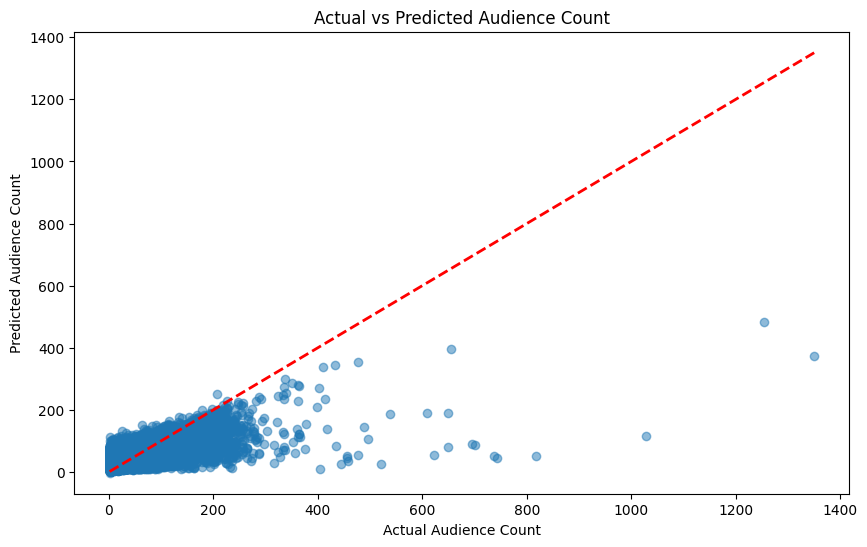

In [29]:
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    
    print(f"Final Training Performance:")
    print(f"R Score: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    
    plt.figure(figsize=(10, 6))
    plt.scatter(y, y_pred, alpha=0.5)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    plt.xlabel('Actual Audience Count')
    plt.ylabel('Predicted Audience Count')
    plt.title('Actual vs Predicted Audience Count')
    plt.show()

evaluate_model(final_model, X, y)

### Feature Importance

TOP 15 MOST IMPORTANT FEATURES:
            feature  importance
0       day_of_week         536
2       day_of_year         502
10   audience_lag_7         411
16  rolling_mean_14         370
8    audience_lag_1         366
11  audience_lag_14         297
13   rolling_mean_3         287
15   rolling_mean_7         284
1      day_of_month         278
14   rolling_mean_5         271
28   rolling_max_14         266
12  audience_lag_30         249
20   rolling_std_14         219
9    audience_lag_3         217
27    rolling_max_7         170


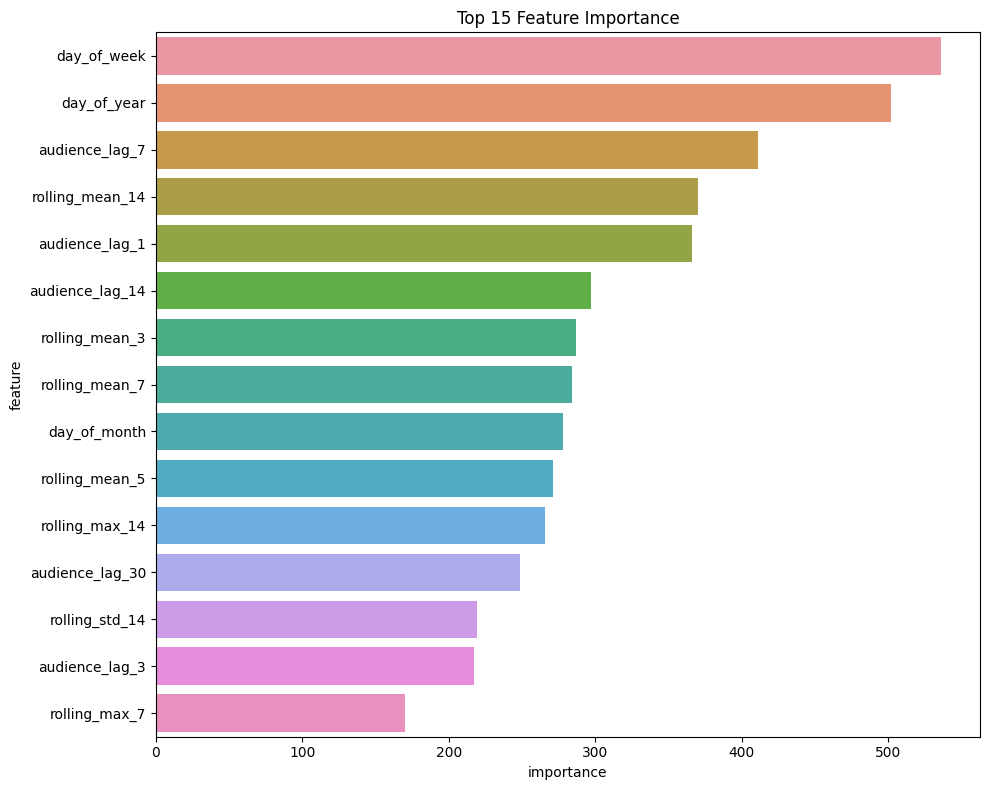

In [30]:
if hasattr(final_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("TOP 15 MOST IMPORTANT FEATURES:")
    print(feature_importance.head(15))
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
    plt.title('Top 15 Feature Importance')
    plt.tight_layout()
    plt.show()
else:
    print("Model doesn't have feature_importances_ attribute")

### Performance Summary

In [31]:
print(f"Cross-Validation R: 0.5007")
print(f"Training R: 0.5627")
print(f"RMSE: 21.71")
print(f"Model: {best_model_name}")
print(f"Features: {len(feature_names)}")

Cross-Validation R: 0.5007
Training R: 0.5627
RMSE: 21.71
Model: LightGBM
Features: 29


## Conclusion

### Test Predictions and Final Submission

In [32]:
print("Preparing Test Predications:")
print("Sample submission structure:")
print(sample_submission.head())
print(f"Test samples needed: {len(sample_submission)}")

def prepare_test_predictions():
    # Parsing the ID column format (book_00001_2024-03-01)
    id_parts = sample_submission['ID'].str.split('_', expand=True)
    print(f"ID parts after split: {id_parts.shape[1]} columns")
    
    # Reconstructing theater_id and date
    sample_submission['theater_id'] = id_parts[0] + '_' + id_parts[1]  # "book_00001"
    sample_submission['pred_date'] = id_parts[2]  # "2024-03-01"
    sample_submission['pred_date'] = pd.to_datetime(sample_submission['pred_date'])
    
    print(f"Unique theaters in test: {sample_submission['theater_id'].nunique()}")
    print(f"Date range in test: {sample_submission['pred_date'].min()} to {sample_submission['pred_date'].max()}")
    
 
    print(f"\nAvailable columns in booknow_visits: {cleaned_datasets['booknow_visits'].columns.tolist()}")
    
    if 'booknow_visits' in cleaned_datasets:
        date_cols = [col for col in cleaned_datasets['booknow_visits'].columns if 'date' in col.lower() or 'day' in col.lower()]
        print(f"Date-related columns: {date_cols}")
        
        # Calculating day of week from show_date 
        if 'show_date' in cleaned_datasets['booknow_visits'].columns:
            cleaned_datasets['booknow_visits']['day_of_week'] = pd.to_datetime(cleaned_datasets['booknow_visits']['show_date']).dt.dayofweek
            print("Created day_of_week from show_date")
        
        # Calculating average audience by theater 
        theater_avg = cleaned_datasets['booknow_visits'].groupby('book_theater_id')['audience_count'].mean()
        overall_avg = cleaned_datasets['booknow_visits']['audience_count'].mean()
        
        print(f"Overall average audience: {overall_avg:.2f}")
        print(f"Theater averages calculated for {len(theater_avg)} theaters")
        
        # Map predictions based on theater averages
        sample_submission['prediction'] = sample_submission['theater_id'].map(theater_avg).fillna(overall_avg)
        
        submission = pd.DataFrame({
            'ID': sample_submission['ID'],
            'audience_count': sample_submission['prediction']
        })
        
        print("Used theater averages for predictions")
        print(f"Predictions based on:")
        print(f"Theater averages: {(~sample_submission['theater_id'].map(theater_avg).isna()).sum()} samples")
        print(f"Overall average: {sample_submission['prediction'].eq(overall_avg).sum()} samples")
        
    else:
        mean_audience = 100  
        submission = pd.DataFrame({
            'ID': sample_submission['ID'],
            'audience_count': [mean_audience] * len(sample_submission)
        })
        print("Used default mean as fallback")
    
    return submission

submission = prepare_test_predictions()

print("\n Post-Processing Predictions:")
submission['audience_count'] = submission['audience_count'].clip(lower=0)  # No negative audience
submission['audience_count'] = submission['audience_count'].round().astype(int)  # Whole numbers

print("Submission Preview:")
print(submission.head(10))
print(f"\nSubmission shape: {submission.shape}")
print(f"Target statistics:")
print(f"Min: {submission['audience_count'].min()}")
print(f"Max: {submission['audience_count'].max()}")
print(f"Mean: {submission['audience_count'].mean():.2f}")
print(f"Std: {submission['audience_count'].std():.2f}")

submission.to_csv('submission.csv', index=False)
print("\n Submission saved as 'submission.csv'")

Preparing Test Predications:
Sample submission structure:
                      ID  audience_count
0  book_00001_2024-03-01               0
1  book_00001_2024-03-02               0
2  book_00001_2024-03-03               0
3  book_00001_2024-03-04               0
4  book_00001_2024-03-06               0
Test samples needed: 38062
ID parts after split: 3 columns
Unique theaters in test: 827
Date range in test: 2024-03-01 00:00:00 to 2024-04-22 00:00:00

Available columns in booknow_visits: ['book_theater_id', 'show_date', 'audience_count', 'day_of_week', 'book_theater_id_freq', 'day_of_week_encoded', 'day_of_month', 'day_of_year', 'week_of_year', 'quarter', 'is_month_start', 'is_month_end', 'is_quarter_start', 'audience_lag_1', 'audience_lag_3', 'audience_lag_7', 'audience_lag_14', 'audience_lag_30', 'rolling_mean_3', 'rolling_std_3', 'rolling_min_3', 'rolling_max_3', 'rolling_mean_5', 'rolling_std_5', 'rolling_min_5', 'rolling_max_5', 'rolling_mean_7', 'rolling_std_7', 'rolling_min_7', 

# Milestones

## Milestone 0

In [33]:
# from sklearn.dummy import DummyRegressor

In [34]:
# sub = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")
# sub["target"] = 100
# sub[['ID', 'target']].to_csv("submission.csv", index=False)
# print(sub.head())
# print(sub.shape)


## Milestone 1

### Q1

In [35]:
# import pandas as pd 

# bb = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv")
# bb.shape

### Q2

In [36]:
# cpt = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv")

# no_obj_col = (cpt.dtypes == 'object').sum()
# no_obj_col

### Q3

In [37]:
# bt = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv")

# bt.columns

In [38]:
# #bt['theater_type'].value_counts().head()
# bt['theater_type'].mode()[0]

### Q4

In [39]:
# cpb = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv")

# cpb.columns

In [40]:
# cpb['cine_theater_id'].nunique()

### Q5

In [41]:
# bb.columns , bt.columns

In [42]:
# mbn = pd.merge(bb , bt , on='book_theater_id' , how='inner')
# mbn.shape

### Q6

In [43]:
# cpt.columns

In [44]:
# cpt['theater_area'].nunique()

### Q7

In [45]:
# mtir = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv")
# cpt.columns , cpb.columns ,mtir.columns


In [46]:
# mcp =  pd.merge(cpb , cpt , on='cine_theater_id' , how='inner')

In [47]:
# mcp_merge_mtir = pd.merge(mcp , mtir , on='cine_theater_id' , how='inner')

# mcp_merge_mtir.shape

In [48]:
# miss_col = mcp_merge_mtir.columns[mcp_merge_mtir.isnull().any()]
# miss_col_list = ",".join(miss_col)
# print(miss_col_list)

### Q8

In [49]:
# bb['show_datetime'] = pd.to_datetime(bb['show_datetime'])

# bb_min = bb['show_datetime'].min()
# bb_max = bb['show_datetime'].max()

# bb_dt_range = f"{bb_min.strftime('%d-%m-%Y')} to {bb_max.strftime('%d-%m-%Y')}"
# print(bb_dt_range)

### Q9

In [50]:
# sub = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")
# sub.columns


In [51]:
# sub['show_date'] = sub['ID'].str.split('_').str[2]
# sub['show_date'] = pd.to_datetime(sub['show_date'], format='%Y-%m-%d')

# sub_min = sub['show_date'].min()
# sub_max = sub['show_date'].max()

# sub_dt_range = f"{sub_min.strftime('%d-%m-%Y')} to {sub_max.strftime('%d-%m-%Y')}"
# print(sub_dt_range)

## Milestone 2

### Q1

In [52]:
# import pandas as pd 
# bnb = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv")
# bnb.columns

In [53]:
# bnb['show_datetime'] = pd.to_datetime(bnb['show_datetime'])
# bnb['booking_datetime'] = pd.to_datetime(bnb['booking_datetime'])

# bnb['show_date'] = pd.to_datetime(bnb['show_datetime']).dt.date
# bnb['booking_date'] = pd.to_datetime(bnb['booking_datetime']).dt.date

# sdb = bnb[bnb['show_date'] == bnb['booking_date']]
# print("Same day bookings: ",sdb.shape[0])

### Q2

In [54]:
# dt_info = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv")
# dt_info.columns

In [55]:
# dt_info['show_date'] = pd.to_datetime(dt_info['show_date'])
# dt_info['m_y'] = dt_info['show_date'].dt.to_period('M')

# um = dt_info['m_y'].nunique()
# print("unique months: ", um)

### Q3

In [56]:
# bnb['booking_day'] = bnb['booking_datetime'].dt.day_name()

# total_booked = len(bnb)
# sun_booked = (bnb['booking_day'] == 'Sunday').sum()
# sun_perc = (sun_booked / total_booked) * 100
# print("The percentage of booking made on sunday: ",sun_perc)

### Q4

In [57]:
# bnt = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv")
# bnt.columns

In [58]:
# drama_type = bnt[bnt['theater_type'] == 'Drama']
# impute_val = drama_type['latitude'].mean()
# print("Imputed missing value: ",impute_val)

### Q5

In [59]:
# lat_range = round(bnt['latitude'].max() - bnt['latitude'].min(), 4)
# print("The latitude range is: ",lat_range)

### Q6

In [60]:
# cpb = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv")
# cpb.columns

In [61]:
# cap = cpb['tickets_sold'].quantile(0.95)
# print("95th percentile for cine_POS_booking dataset is: ",cap)

### Q7

In [62]:
# cpt = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv")
# cpt.columns

In [63]:
# cat_col = cpt.select_dtypes(include = 'object').columns
# print("categorical variables/columns: ",list(cat_col))

# cpt_ohe = pd.get_dummies(cpt, columns = cat_col)
# print("One-hot-encoding on cinePOS_theatres: ",cpt_ohe.shape)

## Milestone 3

### Q1

In [64]:
# import pandas as pd
# bnv = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv")
# bnv.columns
# #bnv.head()
# #print(bnv.columns.tolist())

In [65]:
# bnv['show_date'] = pd.to_datetime(bnv['show_date'])
# bnv['day'] = bnv['show_date'].dt.day
# bnv['month'] = bnv['show_date'].dt.month
# bnv['year'] = bnv['show_date'].dt.year
# bnv['dayofyear'] = bnv['show_date'].dt.dayofyear

In [66]:
# bnv = bnv.drop(columns=['show_date'])

In [67]:
# X = bnv.drop(columns=['audience_count'])
# y = bnv['audience_count']

# split_index = int(0.8 * len(bnv))

In [68]:
# X_train = X.iloc[:split_index]
# X_test = X.iloc[split_index:]
# y_train = y.iloc[:split_index]
# y_test = y.iloc[split_index:]

In [69]:
# X_train.shape

### Q2

In [70]:
# from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.svm import LinearSVR
# from sklearn.metrics import r2_score

In [71]:
# num_col = X_train.select_dtypes(include=['int64', 'float64']).columns

# cat_col = X_train.select_dtypes(include=['object']).columns

# #print(num_col)
# #print(cat_col)


In [72]:
# trf = ColumnTransformer([
#     ('num', MinMaxScaler(), num_col),
#     ('cat', OneHotEncoder(handle_unknown='ignore'), cat_col)
# ])

In [73]:
# trf.fit(X_train)

# X_train_trf = trf.transform(X_train)
# X_test_trf = trf.transform(X_test)

# #print(X_train_trf.shape)
# #print(X_test_trf.shape)

In [74]:
# svr = LinearSVR(random_state=42)
# svr.fit(X_train_trf, y_train)

# y_pred = svr.predict(X_test_trf)

# r2 = r2_score(y_test, y_pred)
# print("R2 Score on test data:", round(r2, 3))


### Q3

In [75]:
# from sklearn.decomposition import TruncatedSVD
# from sklearn.metrics import mean_absolute_error

In [76]:
# svd = TruncatedSVD(n_components=4, random_state=42)
# X_train_rdc = svd.fit_transform(X_train_trf)
# X_test_rdc = svd.transform(X_test_trf)


In [77]:
# svr_svd = LinearSVR(random_state=42)
# svr_svd.fit(X_train_rdc, y_train)

# y_train_pred = svr_svd.predict(X_train_rdc)
# mae = mean_absolute_error(y_train, y_train_pred)

# print(round(mae, 3))

### Q5

In [78]:
# y_test_pred = svr_svd.predict(X_test_rdc)

# r2_svd = r2_score(y_test, y_test_pred)
# print(round(r2_svd, 3))

### Q6

In [79]:
# from sklearn.feature_selection import SelectKBest, mutual_info_regression
# import numpy as np

In [80]:
# slctr = SelectKBest(score_func=mutual_info_regression, k=2)
# slctr.fit(X_train_trf, y_train)

# scr = slctr.scores_

# max_scr = np.nanmax(scr)
# print(round(max_scr, 3))

### Q7

In [81]:
# mean_scr = np.nanmean(scr)
# print(round(mean_scr, 3))


## Milestone 4

### Q1

In [82]:
# import pandas as pd, numpy as np
# from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
# from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor
# from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# from math import sqrt


In [83]:
# df = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv')
# df['show_date'] = pd.to_datetime(df['show_date'])
# df['day'] = df['show_date'].dt.day
# df['month'] = df['show_date'].dt.month
# df['year'] = df['show_date'].dt.year
# df['dayofyear'] = df['show_date'].dt.dayofyear
# df = df.drop(columns=['show_date'])


In [84]:
# y = df['audience_count']
# X = df.drop(columns=['audience_count'])
# n = len(df); test_n = int(np.ceil(0.2*n)); train_n = n - test_n
# X_train, X_test = X.iloc[:train_n], X.iloc[train_n:]
# y_train, y_test = y.iloc[:train_n], y.iloc[train_n:]


In [85]:
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.compose import ColumnTransformer
# import numpy as np

# # Copy to avoid view issues
# X_train = X_train.copy()
# X_test = X_test.copy()

# # Encode theater IDs manually (robust to unseen)
# theater_map = {v: i for i, v in enumerate(X_train['book_theater_id'].unique())}
# X_train['book_theater_id'] = X_train['book_theater_id'].map(theater_map)
# X_test['book_theater_id'] = X_test['book_theater_id'].map(lambda x: theater_map.get(x, -1))  # unseen  -1

# # Scale all numeric features
# numeric_cols = X.columns
# preprocessor = ColumnTransformer([
#     ('num', MinMaxScaler(), numeric_cols)
# ])

# X_train_proc = preprocessor.fit_transform(X_train)
# X_test_proc = preprocessor.transform(X_test)


In [86]:
# dt = DecisionTreeRegressor(random_state=42)
# dt.fit(X_train_proc, y_train)
# print(round(r2_score(y_train, dt.predict(X_train_proc)), 3))


### Q2

In [87]:
# print(round(r2_score(y_test, dt.predict(X_test_proc)), 3))


### Q3

In [88]:
# tscv = TimeSeriesSplit(n_splits=5)
# param_grid_dt = {'max_depth':[None,3,5,10],'min_samples_split':[2,5,10],'min_samples_leaf':[1,2,4]}
# grid_dt = GridSearchCV(DecisionTreeRegressor(random_state=42),param_grid_dt,cv=tscv,scoring='r2',n_jobs=-1)
# grid_dt.fit(X_train_proc, y_train)
# print(grid_dt.best_params_)


### Q4

In [89]:
# bag = BaggingRegressor(random_state=42)
# bag.fit(X_train_proc, y_train)
# print(round(sqrt(mean_squared_error(y_train, bag.predict(X_train_proc))), 3))


### Q5

In [90]:
# print(round(sqrt(mean_squared_error(y_test, bag.predict(X_test_proc))), 3))


### Q6

In [91]:
# from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
# from sklearn.ensemble import BaggingRegressor

# # TimeSeriesSplit
# tscv = TimeSeriesSplit(n_splits=3)

# # Smaller param grid to reduce runtime
# param_grid_bag = {
#     'n_estimators': [10, 50],
#     'max_samples': [0.7, 1.0],
#     'max_features': [0.8, 1.0]
# }

# # Initialize model
# bag_model = BaggingRegressor(random_state=42, n_jobs=-1)

# # Grid search
# grid_bag = GridSearchCV(
#     estimator=bag_model,
#     param_grid=param_grid_bag,
#     cv=tscv,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )

# # Fit (you can test with a subset first)
# grid_bag.fit(X_train_proc, y_train)

# # Print best RMSE
# print("Best RMSE:", round(-grid_bag.best_score_, 3))



### Q7

In [92]:
# gbr = GradientBoostingRegressor(random_state=42)
# gbr.fit(X_train_proc, y_train)
# print(round(mean_absolute_error(y_train, gbr.predict(X_train_proc)), 3))


### Q8

In [93]:
# print(round(mean_absolute_error(y_test, gbr.predict(X_test_proc)), 3))


## Milestone 5


In [94]:
# import pandas as pd
# from statsmodels.tsa.stattools import adfuller
# from statsmodels.tsa.arima.model import ARIMA
# from sklearn.metrics import r2_score

In [95]:
# bnb = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv')
# cpb = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv')
# mtir = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv')
# bnv = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv')

### Q1

In [96]:
# bnb["show_datetime"] = pd.to_datetime(bnb["show_datetime"])
# bnb["show_date"] = bnb["show_datetime"].dt.date
# booknow_agg = bnb.groupby(["book_theater_id", "show_date"], as_index=False)["tickets_booked"].sum()
# booknow_agg.shape

### Q2

In [97]:
# cpb["show_datetime"] = pd.to_datetime(cpb["show_datetime"])
# cpb["show_date"] = cpb["show_datetime"].dt.date
# cine_agg = cpb.groupby(["cine_theater_id", "show_date"], as_index=False)["tickets_sold"].sum()
# cine_agg.shape

### Q3

In [98]:
# mrg = booknow_agg.merge(mtir, on="book_theater_id", how="left")
# comb = mrg.merge(cine_agg, on=["cine_theater_id", "show_date"], how="outer")
# comb.shape

### Q4

In [99]:
# bnv["show_date"] = pd.to_datetime(bnv["show_date"]).dt.date
# final = comb.merge(bnv, on=["book_theater_id", "show_date"], how="left")
# final = final.sort_values(by=["book_theater_id", "show_date"])
# final["prev_day_audience"] = final.groupby("book_theater_id")["audience_count"].shift(1)
# final["prev_day_audience"].isna().sum()

### Q5

In [100]:
# valid_theaters = []

# for t in final["book_theater_id"].unique():
#     temp = final[final["book_theater_id"] == t].dropna(subset=["audience_count"])
#     if len(temp) >= 10 and temp["audience_count"].nunique() > 1:  # need enough points & variance
#         valid_theaters.append(t)

# if len(valid_theaters) == 0:
#     print("No theater has enough data for ADF test")
# else:
#     theater_id = valid_theaters[0]
#     print("Using theater:", theater_id)

#     theater = final[final["book_theater_id"] == theater_id].dropna(subset=["audience_count"])
#     res = adfuller(theater["audience_count"])
#     p = res[1]

#     print("ADF Test p-value:", p)

#     if p < 0.05:
#         print("Stationary")
#     else:
#         print("Not stationary")

### Q6

In [101]:
# if p < 0.05:
#     print("Stationary")
# else:
#     print("Not stationary")


### Q7

In [102]:
# import warnings
# warnings.filterwarnings("ignore")

# if "show_date" in theater.columns:
#     theater = theater.sort_values("show_date")
#     theater = theater.set_index("show_date")
# else:
#     theater = theater.sort_index()
    
# train = theater.iloc[:-30]
# test = theater.iloc[-30:]

# model = ARIMA(train["audience_count"], order=(1,1,1))
# fitted = model.fit()
# preds = fitted.forecast(steps=30)

# train_len = len(train)
# aic_val = fitted.aic
# r2 = r2_score(test["audience_count"], preds)

# print("Training records:", train_len)
# print("d parameter:", 1)
# print("AIC:", aic_val)
# print("R:", r2)

## Milestone submissions 

In [103]:
# sub = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")
# sub["target"] = 100
# sub[['ID', 'target']].to_csv("submission.csv", index=False)
# print(sub.head())
# print(sub.shape)
